In [1]:
import json
from pathlib import Path
from typing import Dict, Any, List, Optional

import matplotlib.pyplot as plt

In [2]:
def load_run_summary(run_dir: Path, fields_lst: List[str]) -> Dict[str, Any]:
    """
    Load <run_dir>/summary.json and return the sections specified in fields_lst
    """
    run_dir = Path(run_dir).expanduser().resolve()
    summary_path = run_dir / "summary.json"
    if not summary_path.exists():
        raise FileNotFoundError(f"summary.json not found: {summary_path}")

    data: Dict[str, Any] = json.loads(summary_path.read_text(encoding="utf-8"))

    dict_out = {}
    for field in fields_lst:
        dict_out.update({
            field: data.get(field, {})
        })

    return dict_out
      
def load_multiple_runs(run_dirs: List[Path], fields_lst: List[str]) -> Dict[str, Dict[str, Any]]:
    """
    Returns:
      dict mapping run_name -> {group -> accuracy}
    where group is "overall" or a level string like "1", "2", ...
    """
    out: Dict[str, Dict[str, Any]] = {}
    for rd in run_dirs:
        rd = Path(rd).expanduser().resolve()
        run_name = rd.name
        out[run_name] = load_run_summary(rd, fields_lst)
    return out

In [15]:
def plot_grouped_bars(
      run_data: Dict[str, Dict[str, Dict[str, float]]],
      metrics: List[str],
      title: str = "Run accuracies by level",
      out_path: Optional[Path] = None,
  ) -> None:
      """
      One grouped bar plot per metric.

      Args:
        run_data : { run_name -> { group -> { metric -> value } } }
                   where group is "overall", "1", "2", ...
        metrics  : list of metric keys to plot (one subplot per metric)
        title    : base title; metric name is appended per subplot
        out_path : if given, save figure here (PNG/PDF etc.)
      """
      if not run_data:
          print("[WARN] No runs provided.")
          return

      runs = list(run_data.keys())

      all_groups: set = set()
      for stats in run_data.values():
          all_groups.update(stats.keys())

      def group_key(g: str):
          if g == "overall":
              return (-1, -1)
          try:
              return (0, int(g))
          except Exception:
              return (1, g)

      groups = sorted(all_groups, key=group_key)
      labels = ["overall" if g == "overall" else f"level {g}" for g in groups]

      n_groups = len(groups)
      n_runs = len(runs)
      n_metrics = len(metrics)

      x = list(range(n_groups))
      width = 0.8 / max(1, n_runs)

      fig, axes = plt.subplots(
          n_metrics, 1,
          figsize=(max(8, n_groups * 1.2), 4.0 * n_metrics),
          squeeze=False,
      )

      for row, metric in enumerate(metrics):
          ax = axes[row][0]
          for i, run in enumerate(runs):
              offsets = [xi - 0.4 + width / 2 + i * width for xi in x]
              heights = [run_data[run].get(g, {}).get(metric, 0.0) for g in groups]
              ax.bar(offsets, heights, width=width, label=run)

          ax.set_xticks(x)
          ax.set_xticklabels(labels)
          ax.set_ylim(0.0, 1.0)
          ax.set_ylabel(metric)
          ax.set_title(f"{metric}")
          # ax.set_title(f"{title} — {metric}")
          ax.legend()

      fig.tight_layout()

      if out_path:
          out_path = Path(out_path).expanduser().resolve()
          out_path.parent.mkdir(parents=True, exist_ok=True)
          fig.savefig(out_path, dpi=200)
          print(f"Saved plot to: {out_path}")

      plt.show()

In [17]:
run_dir = r'G:\My Drive\Gkioxari_Lab\StateWMBench\StateWM\runs'

runs = ['veo_output_map_veo_run_2', "HY-WorldPlay_output_map_hunyuan_run_1"]
fields = ['overall', "by_level", "num_tasks"]
run_stats = load_multiple_runs([f"{run_dir}\\{r}" for r in runs], fields_lst=fields)

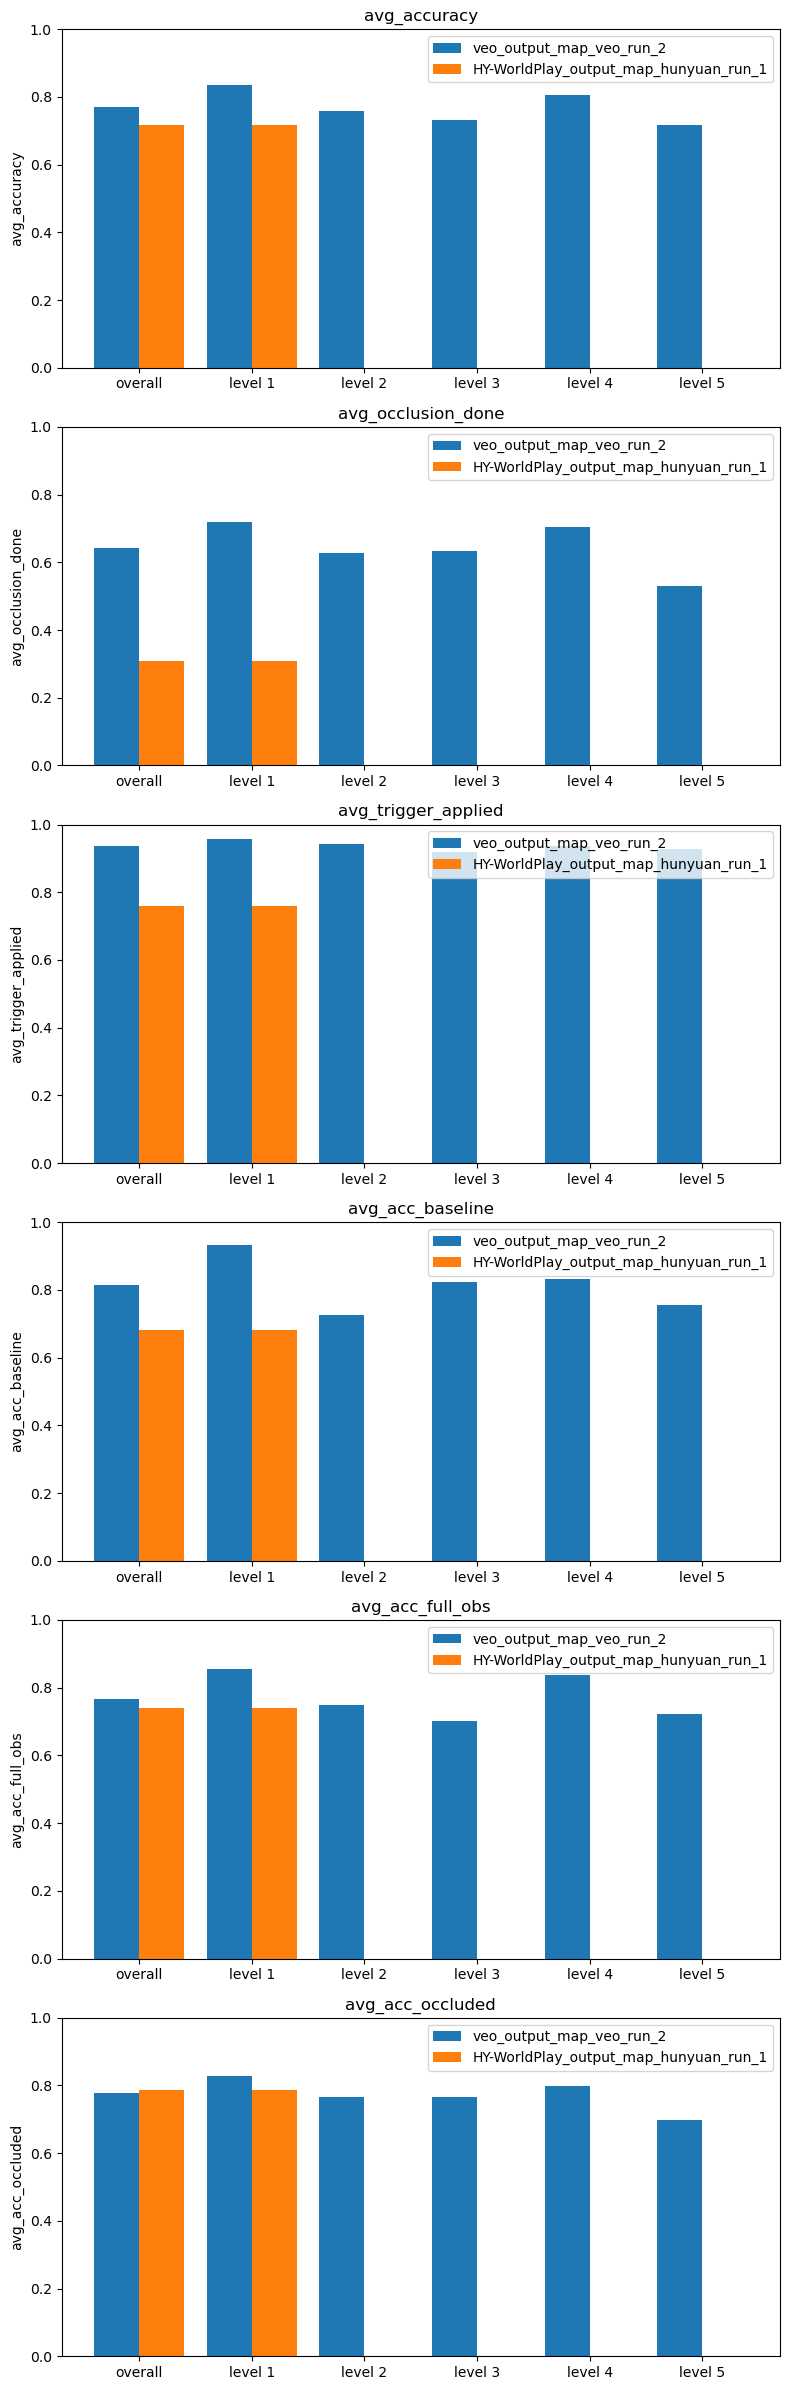

In [ ]:
flat_data = {}
for run_name, data in run_stats.items():
    flat_data[run_name] = {"overall": data["overall"], **data["by_level"]}

metric_lst = ['avg_success', "avg_compliant", "avg_success_compliant"]

plot_grouped_bars(flat_data, metric_lst)